## Avaliação dos modelos testados

**Objetivo:** comparar as configurações finais dos modelos testados: SARIMAX, LightGBM, XGBoost e LSTM para definir o modelo final.

Na comparação foi usando somente o conjunto de teste.
- Conjunto de dados:

      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00




In [66]:
%matplotlib widget

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


In [68]:
#abrindo resultados do conjunto de validação (Melhor SARIMAX)
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_test.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

In [69]:
#abrindo resultados do melhor ajuste para o LightGBM
lgbm = pd.read_csv('../results/walk_forward_lgbm_test.csv')
lgbm["inicio_previsao"] = pd.to_datetime(lgbm["inicio_previsao"])
#lgbm = lgbm.iloc[:-1]
lgbm.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,8.558701,10.817917,0.591992,18.166667,24.262454,-1.052345,52.887882,55.412931
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,5.192289,6.738938,0.086660,6.666667,8.341663,-0.399441,22.115667,19.213484
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,5.689295,7.127129,0.489452,9.666667,11.765061,-0.391219,41.145221,39.421236
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,5.859718,7.251251,0.213564,12.500000,14.753531,-2.255589,53.122256,50.850742
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,5.749311,7.092264,-0.070257,10.791667,13.569267,-2.917698,46.724529,47.732887


In [70]:
#abrindo resultados do melhor ajuste para o XGboost
xgboost = pd.read_csv('../results/walk_forward_xgboost_test.csv')
xgboost["inicio_previsao"] = pd.to_datetime(xgboost["inicio_previsao"])
#xgboost = xgboost.iloc[:-1]
xgboost.head()

,start,inicio_previsao,fim_previsao,mes,n_obs,mae_xgboost,rmse_xgboost,r2_xgboost,mae_baseline,rmse_baseline,r2_baseline,melhora_mae_%,melhora_rmse_%
0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,8.576213,10.780247,0.594829,18.166667,24.262454,-1.052345,52.791488,55.568191
1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,5.358290,6.881829,0.047517,6.666667,8.341663,-0.399441,19.625655,17.500506
2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,5.592222,7.140303,0.487563,9.666667,11.765061,-0.391219,42.149422,39.309258
3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,6.010634,7.411380,0.178446,12.500000,14.753531,-2.255589,51.914931,49.765380
4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,6.164061,7.566968,-0.218322,10.791667,13.569267,-2.917698,42.881289,44.234512


In [71]:
#abrindo resultados do melhor ajuste para o LSTM
lstm = pd.read_csv('../results/estrategia_3_lstm.csv')
lstm["inicio_previsao"] = pd.to_datetime(lstm["inicio_previsao"])
lstm.head()

,index,start,inicio_previsao,fim_previsao,mes,n_obs,mae_lstm,rmse_lstm,mae_baseline,melhora_mae_%
0,0,0,2019-01-01 00:00:00+00:00,2019-01-01 23:00:00+00:00,2019-01,24,14.182589,19.478207,18.166667,21.930703
1,1,168,2019-01-08 00:00:00+00:00,2019-01-08 23:00:00+00:00,2019-01,24,6.288872,7.273398,6.666667,5.666919
2,2,336,2019-01-15 00:00:00+00:00,2019-01-15 23:00:00+00:00,2019-01,24,8.914305,11.345972,9.666667,7.783052
3,3,504,2019-01-22 00:00:00+00:00,2019-01-22 23:00:00+00:00,2019-01,24,7.335151,8.917908,12.500000,41.174792
4,4,672,2019-01-29 00:00:00+00:00,2019-01-29 23:00:00+00:00,2019-01,24,6.403906,7.620493,10.791667,40.658783


In [ ]:
#por algum motivo os últimos valores do LSTM parecem com valores altos. Vou tira-los para comprar com o restante.
lstm = lstm.iloc[:-1]

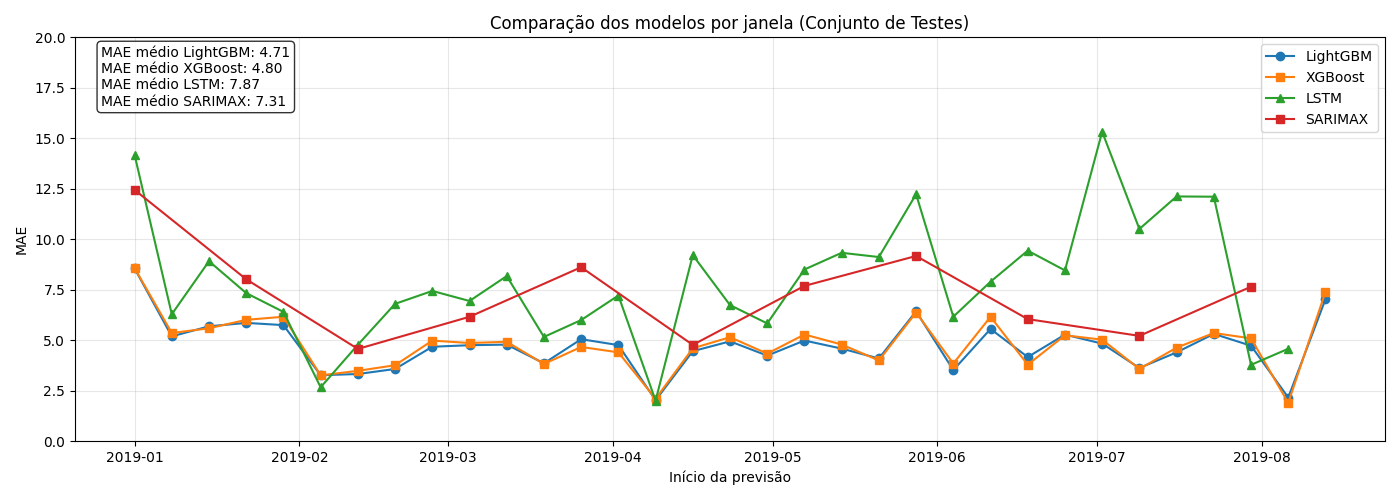

In [73]:
mae_lgbm = lgbm["mae_lgbm"].mean()
mae_lstm = lstm["mae_lstm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()
mae_xgboost = xgboost["mae_xgboost"].mean()

plt.figure(figsize=(14,5))

# LightGBM
plt.plot(
    lgbm["inicio_previsao"],
    lgbm["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

# XGBoost
plt.plot(
    xgboost["inicio_previsao"],
    xgboost["mae_xgboost"],
    marker="s",
    label="XGBoost"
)

texto = (
    f"MAE médio LightGBM: {mae_lgbm:.2f}\n"
    f"MAE médio XGBoost: {mae_xgboost:.2f}\n"
    f"MAE médio LSTM: {mae_lstm:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

# LSTM
plt.plot(
    lstm["inicio_previsao"],
    lstm["mae_lstm"],
    marker="^",
    label="LSTM"
)

# SARIMAX
plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)


plt.text(
    0.02,
    0.98,
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação dos modelos por janela (Conjunto de Testes)")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.ylim([0,20])
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

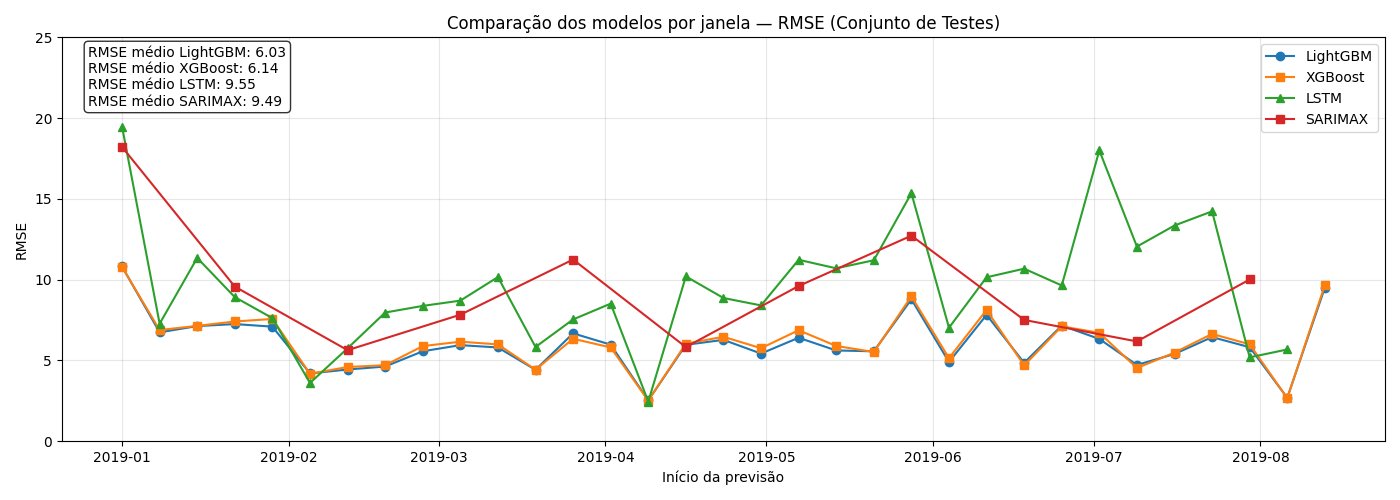

In [74]:
rmse_lgbm = lgbm["rmse_lgbm"].mean()
rmse_lstm = lstm["rmse_lstm"].mean()
rmse_sarimax = best_sarimax["rmse_sarimax"].mean()
rmse_xgboost = xgboost["rmse_xgboost"].mean()

plt.figure(figsize=(14,5))

plt.plot(lgbm["inicio_previsao"], lgbm["rmse_lgbm"], marker="o", label="LightGBM")
plt.plot(xgboost["inicio_previsao"], xgboost["rmse_xgboost"], marker="s", label="XGBoost")
plt.plot(lstm["inicio_previsao"], lstm["rmse_lstm"], marker="^", label="LSTM")
plt.plot(best_sarimax["inicio_previsao"], best_sarimax["rmse_sarimax"], marker="s", label="SARIMAX")

texto = (
    f"RMSE médio LightGBM: {rmse_lgbm:.2f}\n"
    f"RMSE médio XGBoost: {rmse_xgboost:.2f}\n"
    f"RMSE médio LSTM: {rmse_lstm:.2f}\n"
    f"RMSE médio SARIMAX: {rmse_sarimax:.2f}"
)

plt.text(
    0.02, 0.98, texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.title("Comparação dos modelos por janela — RMSE (Conjunto de Testes)")
plt.xlabel("Início da previsão")
plt.ylabel("RMSE")
plt.ylim([0, 25])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()